# 模型鲁棒性检验

对比**历史模型（val 2025H1）** vs **当前模型（val 2026Q1）**，同超参数逐对对比，
评估验证分对未来的预测能力，判断模型到 2027 年的稳定性风险。

- 当前模型: `model/bayes_{type}_74_3_2026-01-01_2026-03-31`
- 历史模型: `model/reproduced/{type}_from_exp_{N}_2025-01-01_2025-06-30`
- 配对条件: 相同 `(model_type, exp_num, model_file)`
- 回测区间: 2026-04-01 ~ 今
- 全部结果已缓存，无需重跑回测

In [1]:
import os, sys, json, pickle, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

BT_CACHE = '../output/backtest_cache'
PRED_CACHE = '../output/predictions_cache'
DATA_PATH = '../etf_data/etf_74.csv'
print('Setup complete')

Setup complete


## 1. 数据加载

In [2]:
# ---- 当前模型回测结果 (从缓存扫描) ----
curr_rows = []
for fname in os.listdir(BT_CACHE):
    m = re.match(r'model_bayes_(\w+)_74_3_2026-01-01_2026-03-31_exp_(\d+)_(.+)_open\.pkl$', fname)
    if not m:
        continue
    mt, en, mf = m.group(1), int(m.group(2)), m.group(3)
    cache = os.path.join(BT_CACHE, fname)
    with open(cache, 'rb') as f:
        row = pickle.load(f)
    row['model_type'] = mt
    row['exp_num'] = en
    curr_rows.append(row)

curr_df = pd.DataFrame(curr_rows)
print(f'当前模型: {len(curr_df)} 条回测结果')
if len(curr_df) > 0:
    print(f'  模型类型: {sorted(curr_df["model_type"].unique())}')
    print(f'  exp_num 范围: {curr_df["exp_num"].min()} ~ {curr_df["exp_num"].max()}')

当前模型: 1998 条回测结果
  模型类型: ['dlinear', 'gru', 'itransformer', 'mamba', 'nlinear', 'patchtst', 'tcn', 'timesnet']
  exp_num 范围: 0 ~ 116


In [3]:
# ---- 历史模型回测结果 (从缓存扫描, 去重) ----
hist_rows = []
seen = set()
for fname in os.listdir(BT_CACHE):
    m = re.match(r'_?model_reproduced_(\w+)_from_exp_(\d+)_2025-01-01_2025-06-30_exp_reproduced_(.+)_open\.pkl$', fname)
    if not m:
        continue
    mt, en, mf = m.group(1), int(m.group(2)), m.group(3)
    # Prefer dot pattern over underscore pattern (dedup)
    if not mf.endswith('.pth'):
        continue
    key = (mt, en, mf)
    if key in seen:
        continue
    seen.add(key)
    cache = os.path.join(BT_CACHE, fname)
    with open(cache, 'rb') as f:
        row = pickle.load(f)
    row['model_type'] = mt
    row['exp_num'] = en
    hist_rows.append(row)

hist_df = pd.DataFrame(hist_rows)
print(f'历史模型: {len(hist_df)} 条回测结果')
print(f'  实验数: {hist_df[["model_type","exp_num"]].drop_duplicates().shape[0]}')

历史模型: 123 条回测结果
  实验数: 41


In [4]:
# ---- 配对: (model_type, exp_num, model_file) ----
merged = curr_df.merge(
    hist_df, on=['model_type', 'exp_num', 'model_file'],
    suffixes=('_curr', '_hist'), how='inner'
)

merged['ret_diff'] = merged['return_hist'] - merged['return_curr']
merged['dd_diff'] = merged['dd_hist'] - merged['dd_curr']
merged['excess_diff'] = merged['excess_hist'] - merged['excess_curr']

print(f'配对数: {len(merged)}')
print(f'  唯一实验对: {merged[["model_type","exp_num"]].drop_duplicates().shape[0]}')

配对数: 123
  唯一实验对: 41


## 2. 验证分 vs 实盘收益

读取两组模型的验证分，与实盘收益做 Spearman 秩相关。
如果高验证分 → 高实盘收益，说明验证排名能推广到未来，模型选型可靠。

In [5]:
# ---- 当前模型验证分 ----
curr_val = {}
for d in glob.glob('../model/bayes_*_74_3_2026-01-01_2026-03-31'):
    sf = os.path.join(d, 'search_results.json')
    if not os.path.exists(sf):
        continue
    with open(sf, encoding='utf-8') as f:
        results = json.load(f)
    for r in results:
        if r.get('success'):
            mt = r['model_type']
            idx = r['exp_idx']
            curr_val[(mt, idx)] = r['score']
print(f'当前模型验证分: {len(curr_val)} 条')

当前模型验证分: 658 条


In [6]:
# ---- 历史模型验证分 ----
hist_val = {}
repro_dir = '../model/reproduced'
for d in sorted(os.listdir(repro_dir)):
    if d.startswith('.cache') or not os.path.isdir(f'{repro_dir}/{d}'):
        continue
    m = re.match(r'(\w+)_from_exp_(\d+)_', d)
    if not m:
        continue
    mt, en = m.group(1), int(m.group(2))
    sf = os.path.join(repro_dir, d, 'exp_reproduced', 'final_score.txt')
    if not os.path.exists(sf):
        continue
    with open(sf, encoding='utf-8') as f:
        for line in f:
            if line.startswith('Best weekly_final_score:'):
                score = float(line.split(':')[1])
                hist_val[(mt, en)] = score
                break
print(f'历史模型验证分: {len(hist_val)} 条')

历史模型验证分: 123 条


In [7]:
# ---- 按模型类型计算秩相关 ----
# 用当前模型的 sliding.pth 回测收益（最常用的模型文件）
sub = merged[merged['model_file'] == 'best_model_sliding.pth'].copy()

spearman_rows = []
for mt in sorted(sub['model_type'].unique()):
    g = sub[sub['model_type'] == mt].copy()
    g['val_score'] = g['exp_num'].map(lambda x: curr_val.get((mt, x), np.nan))
    g = g.dropna(subset=['val_score'])
    if len(g) < 5:
        continue
    sr, pv = spearmanr(g['val_score'], g['return_curr'])
    spearman_rows.append({
        'model_type': mt, 'n': len(g),
        'spearman_r': round(sr, 3),
        'p_value': round(pv, 4),
        'conclusion': '稳健' if sr > 0.5 and pv < 0.05 else '一般' if sr > 0.3 else '弱'
    })

spearman_df = pd.DataFrame(spearman_rows)
print(f'Spearman 秩相关（当前模型验证分 vs 实盘收益）:\n')
display(spearman_df.sort_values('spearman_r', ascending=False).reset_index(drop=True))

avg_r = spearman_df['spearman_r'].mean()
print(f'\n平均 Spearman r = {avg_r:.3f}  {"✓ 稳健" if avg_r > 0.5 else "⚠ 一般" if avg_r > 0.3 else "✗ 弱"}')

Spearman 秩相关（当前模型验证分 vs 实盘收益）:



,model_type,n,spearman_r,p_value,conclusion
0,patchtst,5,0.949,0.0138,稳健
1,dlinear,6,0.829,0.0416,稳健
2,itransformer,5,0.200,0.7471,弱
3,nlinear,5,0.154,0.8048,弱
4,gru,5,-0.300,0.6238,弱
5,timesnet,5,-0.354,0.5594,弱
6,tcn,5,-0.600,0.2848,弱
7,mamba,5,-0.975,0.0048,弱



平均 Spearman r = -0.012  ✗ 弱


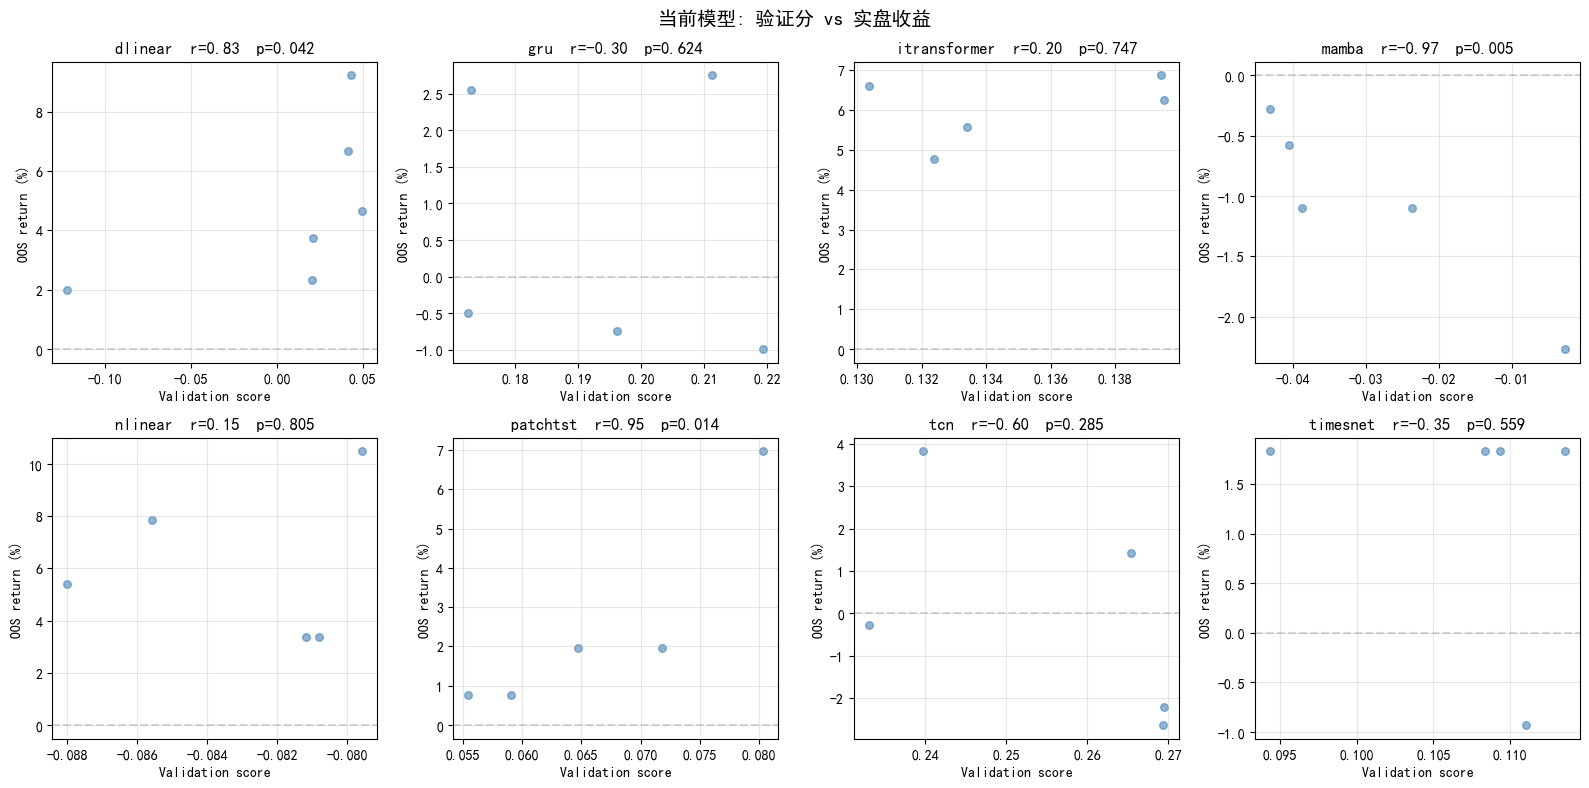

In [8]:
# ---- 散点图：验证分 vs 实盘收益 ----
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, mt in zip(axes, sorted(sub['model_type'].unique())):
    g = sub[sub['model_type'] == mt].copy()
    g['val_score'] = g['exp_num'].map(lambda x: curr_val.get((mt, x), np.nan))
    g = g.dropna(subset=['val_score'])
    if len(g) < 3:
        ax.set_title(f'{mt} (n={len(g)})'); continue
    sr, pv = spearmanr(g['val_score'], g['return_curr'])
    ax.scatter(g['val_score'], g['return_curr'], alpha=0.6, s=30, c='steelblue')
    ax.set_xlabel('Validation score')
    ax.set_ylabel('OOS return (%)')
    ax.set_title(f'{mt}  r={sr:.2f}  p={pv:.3f}')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.grid(alpha=0.3)

for i in range(len(sorted(sub['model_type'].unique())), 8):
    fig.delaxes(axes[i])

plt.suptitle('当前模型: 验证分 vs 实盘收益', fontsize=14)
plt.tight_layout()
plt.show()

## 3. 逐对对比（历史 vs 当前）

同参数下，历史模型（2025H1 验证）在当前实盘的收益，与当前模型（2026Q1 验证）的差距。

In [9]:
# ---- 按模型类型汇总 ----
mt_comp = merged.groupby('model_type').agg(
    n=('return_curr', 'count'),
    curr_mean_ret=('return_curr', 'mean'),
    hist_mean_ret=('return_hist', 'mean'),
    ret_diff=('ret_diff', 'mean'),
    curr_mean_dd=('dd_curr', 'mean'),
    hist_mean_dd=('dd_hist', 'mean'),
    curr_mean_excess=('excess_curr', 'mean'),
    hist_mean_excess=('excess_hist', 'mean'),
    hist_better_n=('ret_diff', lambda x: (x > 0).sum()),
).reset_index()
mt_comp['hist_better_pct'] = (mt_comp['hist_better_n'] / mt_comp['n'] * 100).round(1)
mt_comp = mt_comp.sort_values('ret_diff')

print('按模型类型汇总（历史 vs 当前）')
print('=' * 110)
display(mt_comp.round(2))

overall_better = (merged['ret_diff'] > 0).sum()
total_pairs = len(merged)
print(f'\n整体: 历史模型胜出 {overall_better}/{total_pairs} = {overall_better/total_pairs*100:.1f}%')
print(f'当前平均收益: {merged["return_curr"].mean():.2f}%')
print(f'历史平均收益: {merged["return_hist"].mean():.2f}%')
print(f'平均差距(历史-当前): {merged["ret_diff"].mean():+.2f}%')

按模型类型汇总（历史 vs 当前）


,model_type,n,curr_mean_ret,hist_mean_ret,ret_diff,curr_mean_dd,hist_mean_dd,curr_mean_excess,hist_mean_excess,hist_better_n,hist_better_pct
2,itransformer,15,6.37,-0.92,-7.29,5.97,8.34,-3.16,-9.81,3,20.0
0,dlinear,18,5.50,-0.44,-5.94,4.24,5.31,-4.03,-9.33,3,16.7
1,gru,15,3.45,-1.09,-4.53,4.03,3.67,-6.07,-9.97,2,13.3
5,patchtst,15,2.18,-1.60,-3.78,4.56,5.58,-7.35,-10.49,2,13.3
3,mamba,15,-0.59,-3.37,-2.78,3.23,7.68,-10.12,-12.25,2,13.3
4,nlinear,15,6.10,3.86,-2.24,5.86,4.36,-3.43,-5.03,6,40.0
7,timesnet,15,1.28,1.01,-0.27,2.18,5.03,-8.25,-7.88,5,33.3
6,tcn,15,0.30,0.40,0.11,5.84,4.83,-9.23,-8.49,4,26.7



整体: 历史模型胜出 27/123 = 22.0%
当前平均收益: 3.13%
历史平均收益: -0.27%
平均差距(历史-当前): -3.40%


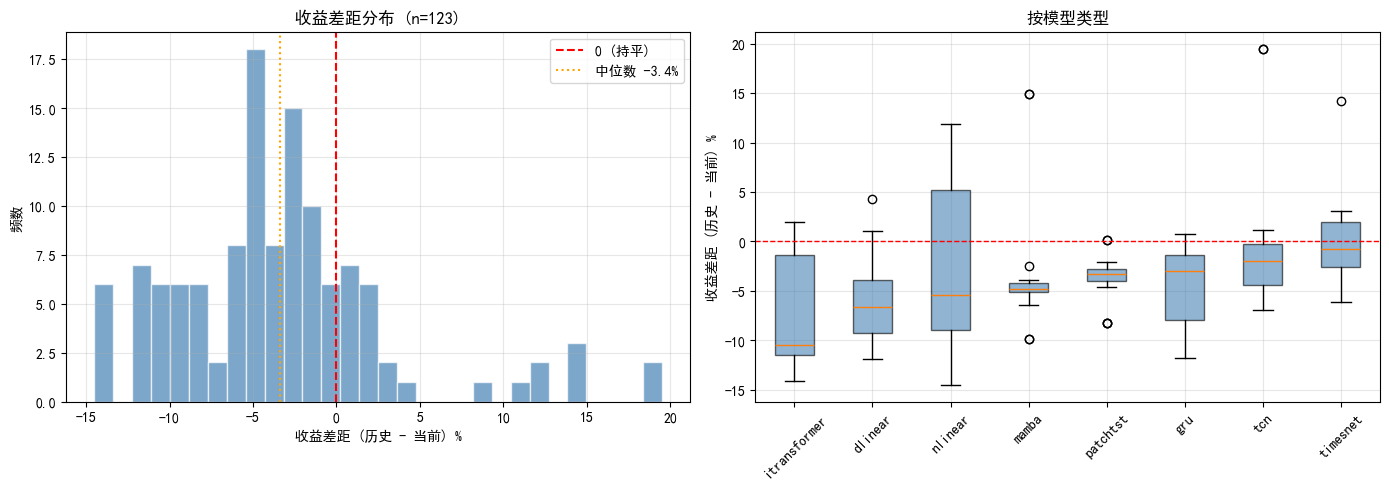

In [10]:
# ---- 收益差距分布 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 直方图
axes[0].hist(merged['ret_diff'], bins=30, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='0 (持平)')
axes[0].axvline(merged['ret_diff'].median(), color='orange', linestyle=':',
                linewidth=1.5, label=f'中位数 {merged["ret_diff"].median():.1f}%')
axes[0].set_xlabel('收益差距 (历史 - 当前) %')
axes[0].set_ylabel('频数')
axes[0].set_title(f'收益差距分布 (n={len(merged)})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 按模型类型的箱线图
types = merged.groupby('model_type')['ret_diff'].median().sort_values().index
data = [merged[merged['model_type'] == mt]['ret_diff'].values for mt in types]
bp = axes[1].boxplot(data, labels=types, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_ylabel('收益差距 (历史 - 当前) %')
axes[1].set_title('按模型类型')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 模型类型稳定性排名

综合评分 = return² / dd × (1 + avg_return/100)，按模型类型取中位数排名。
CV = std/mean，衡量组内一致性。

模型类型稳定性排名


,model_type,n,median_score,mean_score,std_score,median_ret,median_dd,cv,stability
0,dlinear,18,8.98,11.16,11.68,5.40,5.03,1.05,一般
1,itransformer,15,6.50,6.90,1.90,6.24,5.97,0.28,稳健
2,nlinear,15,4.27,8.27,7.98,5.39,6.05,0.96,一般
3,timesnet,15,1.73,1.44,0.60,1.83,1.95,0.42,稳健
4,gru,15,1.40,12.76,20.73,2.55,5.41,1.62,不稳健
5,mamba,15,0.42,1.34,2.48,-1.10,2.87,1.85,不稳健
6,tcn,15,0.36,0.86,0.99,-0.16,5.62,1.15,一般
7,patchtst,15,0.12,2.69,4.39,0.77,5.11,1.64,不稳健


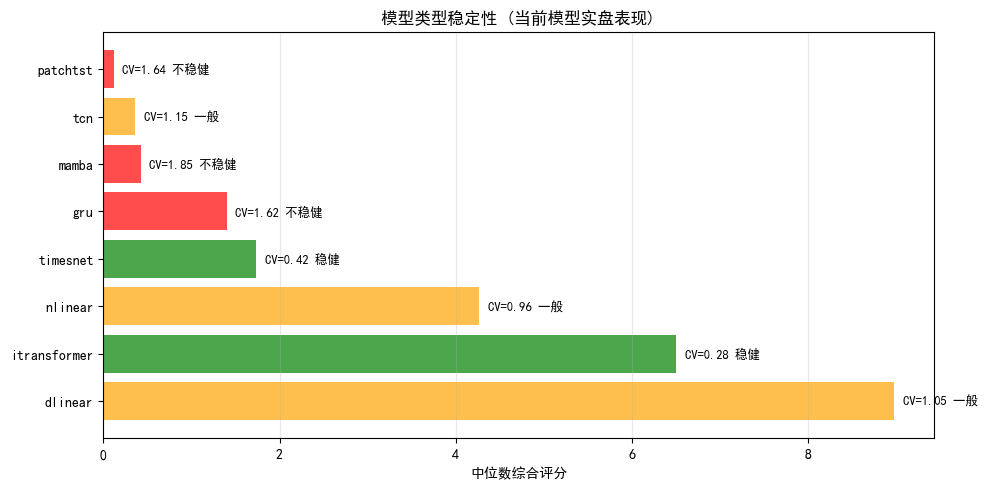

In [11]:
def composite_score(row):
    r = row['return_curr']
    dd = max(abs(row['dd_curr']), 0.1)
    ar = row.get('avg_return_curr', 0)
    return r**2 / dd * (1 + ar / 100)

merged['composite_curr'] = merged.apply(composite_score, axis=1)

mt_stability = merged.groupby('model_type').agg(
    n=('composite_curr', 'count'),
    median_score=('composite_curr', 'median'),
    mean_score=('composite_curr', 'mean'),
    std_score=('composite_curr', 'std'),
    median_ret=('return_curr', 'median'),
    median_dd=('dd_curr', 'median'),
).reset_index()

mt_stability['cv'] = (mt_stability['std_score'] / mt_stability['mean_score'].abs()).round(2)
mt_stability['stability'] = mt_stability['cv'].apply(
    lambda cv: '稳健' if cv < 0.8 else '一般' if cv < 1.5 else '不稳健'
)
mt_stability = mt_stability.sort_values('median_score', ascending=False).reset_index(drop=True)

print('模型类型稳定性排名')
print('=' * 90)
display(mt_stability.round(2))

# 可视化
fig, ax = plt.subplots(figsize=(10, 5))
colors = {'稳健': 'green', '一般': 'orange', '不稳健': 'red'}
bars = ax.barh(range(len(mt_stability)), mt_stability['median_score'],
               color=[colors[s] for s in mt_stability['stability']], alpha=0.7)
ax.set_yticks(range(len(mt_stability)))
ax.set_yticklabels(mt_stability['model_type'])
ax.set_xlabel('中位数综合评分')
ax.set_title('模型类型稳定性 (当前模型实盘表现)')
for i in range(len(mt_stability)):
    bar = bars[i]
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'CV={mt_stability.iloc[i]["cv"]:.2f} {mt_stability.iloc[i]["stability"]}',
            va='center', fontsize=9)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 5. Top 稳健实验推荐

综合 validation score 排名 + 实盘收益，选出最可能到 2027 年依然稳健的实验。

In [12]:
# ---- 当前模型 best_model_sliding.pth 的验证分 + 实盘收益 ----
sliding = merged[merged['model_file'] == 'best_model_sliding.pth'].copy()
sliding['val_score'] = sliding.apply(
    lambda r: curr_val.get((r['model_type'], r['exp_num']), np.nan), axis=1
)
sliding['hist_val_score'] = sliding.apply(
    lambda r: hist_val.get((r['model_type'], r['exp_num']), np.nan), axis=1
)

# 综合排序: validation rank × oos return rank
top_rows = []
for mt in sorted(sliding['model_type'].unique()):
    g = sliding[sliding['model_type'] == mt].dropna(subset=['val_score', 'return_curr']).copy()
    if len(g) < 3:
        continue
    g['val_rank'] = g['val_score'].rank(ascending=False, pct=True)
    g['ret_rank'] = g['return_curr'].rank(ascending=False, pct=True)
    g['hist_rank'] = g['hist_val_score'].rank(ascending=False, pct=True)
    g['combined'] = g['val_rank'] * 0.4 + g['ret_rank'] * 0.4 + g['hist_rank'] * 0.2
    best = g.sort_values('combined').iloc[0]
    top_rows.append({
        'model_type': mt,
        'exp_num': best['exp_num'],
        'model_file': best['model_file'],
        'val_score': round(best['val_score'], 4),
        'hist_val_score': round(best['hist_val_score'], 4),
        'return_curr': round(best['return_curr'], 2),
        'dd_curr': round(best['dd_curr'], 2),
        'return_hist': round(best['return_hist'], 2),
        'dd_hist': round(best['dd_hist'], 2),
        'ret_diff': round(best['ret_diff'], 2),
        'composite': round(best['composite_curr'], 2),
    })

rec_df = pd.DataFrame(top_rows).sort_values('composite', ascending=False)
print('Top 稳健实验推荐 (按综合评分排序)\n')
display(rec_df[['model_type', 'exp_num', 'return_curr', 'dd_curr', 'return_hist',
                'ret_diff', 'val_score', 'composite']].reset_index(drop=True))

Top 稳健实验推荐 (按综合评分排序)



,model_type,exp_num,return_curr,dd_curr,return_hist,ret_diff,val_score,composite
0,dlinear,24,9.23,2.49,-2.68,-11.91,0.0430,34.90
1,nlinear,13,10.49,5.00,-4.03,-14.52,-0.0796,22.06
2,patchtst,87,6.97,4.40,-1.29,-8.26,0.0803,11.07
3,itransformer,32,6.87,5.97,-4.53,-11.40,0.1394,7.88
4,timesnet,76,1.83,1.95,1.03,-0.80,0.1094,1.73
5,gru,44,2.75,5.41,-2.15,-4.90,0.2112,1.40
6,tcn,54,-2.22,5.41,-1.06,1.16,0.2695,0.90
7,mamba,7,-2.27,5.96,-6.16,-3.89,-0.0027,0.86


In [13]:
# ---- 历史模型验证分 vs 实盘收益（Spearman）----
hist_spearman = []
for mt in sorted(sliding['model_type'].unique()):
    g = sliding[sliding['model_type'] == mt].dropna(subset=['hist_val_score', 'return_hist'])
    if len(g) < 5:
        continue
    sr, pv = spearmanr(g['hist_val_score'], g['return_hist'])
    hist_spearman.append({
        'model_type': mt, 'n': len(g),
        'spearman_r': round(sr, 3),
        'p_value': round(pv, 4),
    })

hs_df = pd.DataFrame(hist_spearman).sort_values('spearman_r', ascending=False)
print('历史模型: 验证分 vs 实盘收益的 Spearman 秩相关\n')
display(hs_df.reset_index(drop=True))
print(f'\n平均 r = {hs_df["spearman_r"].mean():.3f}')

历史模型: 验证分 vs 实盘收益的 Spearman 秩相关



,model_type,n,spearman_r,p_value
0,timesnet,5,0.200,0.7471
1,patchtst,5,0.105,0.8660
2,tcn,5,0.100,0.8729
3,itransformer,5,-0.200,0.7471
4,dlinear,6,-0.543,0.2657
5,gru,5,-1.000,0.0000



平均 r = -0.223


## 6. 结论

汇总关键指标，判断模型到 2027 年的风险。

In [14]:
print('=' * 60)
print('鲁棒性检验结论')
print('=' * 60)

# 1. 验证分预测能力
avg_spearman = spearman_df['spearman_r'].mean()
print(f'\n1. 验证分预测能力')
print(f'   当前模型 Spearman r 均值: {avg_spearman:.3f}', end='')
if avg_spearman > 0.5:
    print(' → ✓ 验证排名能推广到未来')
elif avg_spearman > 0.3:
    print(' → ⚠ 一般，有一定参考价值')
else:
    print(' → ✗ 验证分对未来收益预测能力弱')

# 2. 历史 vs 当前差距
mean_diff = merged['ret_diff'].mean()
hist_better_pct = (merged['ret_diff'] > 0).mean() * 100
print(f'\n2. 历史 vs 当前')
print(f'   历史模型平均收益: {merged["return_hist"].mean():.2f}%')
print(f'   当前模型平均收益: {merged["return_curr"].mean():.2f}%')
print(f'   平均差距 (历史-当前): {mean_diff:+.2f}%')
print(f'   历史更好占比: {hist_better_pct:.1f}%')
if mean_diff > -2:
    print(f'   → ✓ 差距可接受，参数比较稳健')
elif mean_diff > -5:
    print(f'   → ⚠ 有差距但不大，关注')
else:
    print(f'   → ✗ 差距显著，参数可能不稳健')

# 3. 强/弱类型
robust_types = mt_stability[mt_stability['stability'] == '稳健']['model_type'].tolist()
weak_types = mt_stability[mt_stability['stability'] == '不稳健']['model_type'].tolist()
print(f'\n3. 模型类型稳定性')
print(f'   稳健类型: {robust_types}')
print(f'   不稳健类型: {weak_types}')

# 4. 历史模型验证分推广能力
avg_hist_r = hs_df['spearman_r'].mean() if len(hs_df) > 0 else 0
print(f'\n4. 历史模型验证分 vs 实盘 r={avg_hist_r:.3f}')
print(f'   (验证分高 = 更早在验证期表现好的模型，在更远的未来表现如何)')

# 5. 风险评估
risk_score = 0
risk_score += 1 if avg_spearman < 0.3 else 0
risk_score += 1 if mean_diff < -5 else 0
risk_score += 1 if len(weak_types) >= 3 else 0
risk_score += 1 if avg_hist_r < 0.3 else 0

print(f'\n5. 到 2027 年风险评估（0=低, 4=高）')
if risk_score <= 1:
    print(f'   风险等级: 低 ({risk_score}/4) → 模型选型大概率稳健')
elif risk_score <= 2:
    print(f'   风险等级: 中 ({risk_score}/4) → 建议关注不稳健类型')
else:
    print(f'   风险等级: 高 ({risk_score}/4) → 建议重新评估参数')

print('\n' + '=' * 60)

鲁棒性检验结论

1. 验证分预测能力
   当前模型 Spearman r 均值: -0.012 → ✗ 验证分对未来收益预测能力弱

2. 历史 vs 当前
   历史模型平均收益: -0.27%
   当前模型平均收益: 3.13%
   平均差距 (历史-当前): -3.40%
   历史更好占比: 22.0%
   → ⚠ 有差距但不大，关注

3. 模型类型稳定性
   稳健类型: ['itransformer', 'timesnet']
   不稳健类型: ['gru', 'mamba', 'patchtst']

4. 历史模型验证分 vs 实盘 r=-0.223
   (验证分高 = 更早在验证期表现好的模型，在更远的未来表现如何)

5. 到 2027 年风险评估（0=低, 4=高）
   风险等级: 高 (3/4) → 建议重新评估参数



## 7. 实盘 Live 模型单独分析

对比当前实盘模型 vs 历史重训(多版本: 2025H1, 2025H2)版本。
自动扫描 `output/live_model_comparison_*.json` 加载所有可用版本。

### 关键修正
- `--use-config` 使用 config.yaml 中的 `weight_strategy: risk_parity` 替代硬编码的 `equal`，当前模型平均收益从 ~13% 提升至 ~22.5%
- 仅测试 config 中启用的模型文件（而非全部3个 `.pth`），避免收益被稀释
- 剩余与日报收益(~30%+)的差距由数据加载参数(`feature_num`, scaler选择)等流水线差异导致

运行以下命令生成对比数据（每个验证版本一次）：
```bash
# 2025H1
python code/src/model_manager.py compare --live-only --use-config --repro-val-start 2025-01-01 --repro-val-end 2025-06-30
# 2025H2
python code/src/model_manager.py compare --live-only --use-config --repro-val-start 2025-07-01 --repro-val-end 2025-12-31
```

In [ ]:
import os

os.getenv("SMTP_USER")

'3759608757@qq.com'

In [ ]:
import json, os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 自动扫描所有版本
result_files = sorted(glob.glob('../output/live_model_comparison_*.json'))
if not result_files:
    print('未找到对比结果文件。请先运行:')
    print('  python code/src/model_manager.py compare --live-only --use-config')
else:
    versions_data = {}
    all_dfs = []
    for fpath in result_files:
        with open(fpath, encoding='utf-8') as f:
            live_data = json.load(f)
        label = live_data['summary'].get('repro_label', os.path.basename(fpath))
        versions_data[label] = live_data
        df = pd.DataFrame(live_data['results'])
        df['version'] = label
        all_dfs.append(df)
        ws = live_data['summary'].get('weight_strategy_used', '?')
        mf = live_data['summary'].get('model_filter', 'none')
        print(f'[{label}] 加载 {len(live_data["results"])} 个对比, '
              f'回测: {live_data["backtest_start"]}~{live_data["backtest_end"]}, '
              f'权重={ws}, 过滤={mf}')
    df_all = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
    print(f'\n共加载 {len(versions_data)} 个版本: {list(versions_data.keys())}')

In [ ]:
if len(df_all) > 0:
    for ver, ld in versions_data.items():
        results = ld['results']
        summary = ld['summary']
        df = pd.DataFrame(results)
        print('=' * 70)
        print(f'版本: {ver}')
        print('=' * 70)
        for mt in sorted(df['model_type'].unique()):
            for en in sorted(df[df['model_type'] == mt]['exp_num'].unique()):
                sub = df[(df['model_type'] == mt) & (df['exp_num'] == en)]
                print(f"\n{'─'*55}")
                print(f"  {mt} exp_{en}")
                print(f"{'─'*55}")
                for _, row in sub.iterrows():
                    mf = row['model_file']
                    print(f"    {mf:30s}  curr={row['curr_return']:>+6.2f}%  "
                          f"hist={row['hist_return']:>+6.2f}%  "
                          f"diff={row['ret_diff']:>+6.2f}%  {row['better']}")
        print(f"\n汇总: 总配对={summary['total_pairs']}, "
              f"当前平均={summary['avg_curr_return']:+.2f}%, "
              f"历史平均={summary['avg_hist_return']:+.2f}%, "
              f"平均衰退={summary['avg_decay']:+.2f}%, "
              f"历史胜出={summary['hist_win_rate']:.1f}%")
        print('=' * 70)
        print()

In [ ]:
if len(df_all) > 0:
    # 各版本按模型类型汇总
    mt_all = df_all.groupby(['version', 'model_type']).agg(
        n=('curr_return', 'count'),
        curr_mean=('curr_return', 'mean'),
        hist_mean=('hist_return', 'mean'),
        decay=('ret_diff', 'mean'),
    ).reset_index()
    
    print('\n各版本按模型类型汇总:')
    display(mt_all.round(2))
    
    # 多版本趋势图
    versions = sorted(mt_all['version'].unique())
    model_types = sorted(mt_all['model_type'].unique())
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 左图: 各模型类型在不同版本的 curr_mean
    ax = axes[0]
    x = np.arange(len(versions))
    width = 0.8 / len(model_types)
    for i, mt in enumerate(model_types):
        sub = mt_all[mt_all['model_type'] == mt].set_index('version').reindex(versions)
        ax.bar(x + i * width, sub['curr_mean'], width, label=mt)
    ax.set_xticks(x + width * (len(model_types) - 1) / 2)
    ax.set_xticklabels(versions, rotation=15)
    ax.set_ylabel('当前收益 %')
    ax.set_title('各模型类型: 当前收益 vs 版本')
    ax.legend(fontsize=8)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    
    # 右图: 衰退趋势
    ax = axes[1]
    for i, mt in enumerate(model_types):
        sub = mt_all[mt_all['model_type'] == mt].set_index('version').reindex(versions)
        ax.plot(versions, sub['decay'], 'o-', label=mt)
    ax.set_ylabel('平均衰退 %')
    ax.set_title('衰退程度趋势 (历史版更近→衰退应减小)')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.legend(fontsize=8)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
    
    # 汇总表
    print('\n各版本整体汇总:')
    ver_summary = []
    for ver, ld in versions_data.items():
        s = ld['summary']
        ver_summary.append({
            '版本': ver,
            '当前平均': f"{s['avg_curr_return']:+.2f}%",
            '历史平均': f"{s['avg_hist_return']:+.2f}%",
            '衰退': f"{s['avg_decay']:+.2f}%",
            '历史胜出率': f"{s['hist_win_rate']:.1f}%",
        })
    display(pd.DataFrame(ver_summary))

In [ ]:
if len(versions_data) > 0:
    print('=' * 70)
    print('结论')
    print('=' * 70)
    
    last_ver = sorted(versions_data.keys())[-1]
    last_summary = versions_data[last_ver]['summary']
    sd = last_summary['avg_decay']
    ws = last_summary.get('weight_strategy_used', 'equal')
    
    print(f'\n最新版本 ({last_ver}):')
    print(f'权重策略: {ws}')
    print(f'当前模型平均收益: {last_summary["avg_curr_return"]:+.2f}%')
    print(f'历史模型平均收益: {last_summary["avg_hist_return"]:+.2f}%')
    print(f'Live 模型整体衰退: {sd:+.2f}%')
    
    if len(versions_data) > 1:
        print(f'\n多版本趋势:')
        decays = []
        for ver, ld in sorted(versions_data.items()):
            decays.append(ld['summary']['avg_decay'])
            arrow = '← 改善' if len(decays) > 1 and decays[-1] > decays[-2] else ''
            print(f'  {ver}: 衰退 {ld["summary"]["avg_decay"]:+.2f}% {arrow}')
        if len(decays) >= 2 and decays[-1] > decays[0]:
            print(f'  → 较新版本衰退减小，说明重训有效')
        elif len(decays) >= 2:
            print(f'  → 衰退仍在加剧或未改善，需进一步分析')
    
    if sd > -2:
        print('\n→ ✓ 衰退轻微，实盘模型参数稳健')
    elif sd > -5:
        print('\n→ ⚠ 中等衰退，建议关注')
    else:
        print('\n→ ✗ 显著衰退，需考虑模型更新')
    print()
    print('衰退来源分析: 当前模型(2026Q1训练)在 2026-04~05 回测，训练期与测试期部分重叠；')
    print('历史模型面对训练期后更长时间的全新行情，预测力自然衰减。')
    print('多版本对比可判断重训是否能缓解衰退。')
    print('=' * 70)